# Unique Solution of Schochastic Fixed-Point Equation

This notebook is to check conjectures in proving that the SFPE
$$X \stackrel{d}{=} I(U^{\alpha}X^{(1)} + (1-U)^{\alpha}X^{(2)}) + J\max(U^{\alpha}X^{(1)}, (1-U)^{\alpha}X^{(2)})$$

has a unique solution $(\alpha^*, X_{\alpha^*})$ such that $\mathbb{E}[X_{\alpha^*}] = 1$.

The classical contraction method does not work: because of the sum, $W_p$ does not work; because of the max, $\zeta_p$ does not work.

In [4]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

#### Monte-Carlo Simulation

In [ ]:
class MeanOneGenerator:
    """
    Generate random distributions of mean 1
    """
    def __init__(self, size=100000):
        self.size = size
        # Bank of base distributions with random shape parameters
        self.distribution_bank = [
            (stats.lognorm, {'s': lambda: np.random.uniform(0.5, 2.0)}),  # Heavy right tail
            (stats.gamma, {'a': lambda: np.random.uniform(0.5, 5.0)}),    # Flexible skew
            (stats.weibull_min, {'c': lambda: np.random.uniform(0.5, 2.0)}), # Extreme value
            (stats.halfcauchy, {'loc': lambda: 0, 'scale': lambda: 1})    # Extreme heavy tail
        ]

    def generate_uniform_shape(self):
      """Generates a uniform distribution with random variance, projected to mean 1."""
      
      width = np.random.uniform(low=0.1, high=0.99)
      
      Z = np.random.uniform(low=1.0 - width, high=1.0 + width, size=self.size)
      X = Z / np.mean(Z) 
    
      return X, "Uniform", {"low": 1.0 - width, "high": 1.0 + width}

    def generate_random_shape(self):
        """Selects a random distribution and randomizes its shape parameters."""
        
        dist_class, param_generators = self.distribution_bank[np.random.randint(0, len(self.distribution_bank))]
        
        # Evaluate the random parameters
        params = {k: v() for k, v in param_generators.items()}
        
        # Generate the unconstrained array (Z)
        Z = dist_class.rvs(**params, size=self.size)
        
        # Project to Mean = 1 (X)
        empirical_mean = np.mean(Z)
        X = Z / empirical_mean
        
        return X, dist_class.name, params

In [10]:
# Sample an iid empirical distribution from another empirical distribution (like a bootstrap)
def sample_from_empirical(X):
    return np.random.choice(X, size=len(X), replace=True)

In [6]:
def plot_distribution(
        particle_array, 
        title="Empirical Distribution", 
        bins=100, clip_percentile=100, 
        log_y=False, show_bins=False, show_kde=True):
    """
    Plots the distribution of a 1D array of particles with optional bins and KDE.
    """
    clean_array = particle_array[np.isfinite(particle_array)]
    
    if clip_percentile < 100:
        max_val = np.percentile(clean_array, clip_percentile)
        view_array = clean_array[clean_array <= max_val]
        clip_note = f" (X-axis clipped at {clip_percentile}th percentile)"
    else:
        view_array = clean_array
        clip_note = ""

    plt.figure(figsize=(10, 6))
    
    if show_bins and show_kde:
        ax = sns.histplot(view_array, bins=bins, kde=True, 
                          stat="density", alpha=0.4)
                        
    elif show_bins and not show_kde:
        ax = sns.histplot(view_array, bins=bins, kde=False, 
                          stat="density", alpha=0.6)
                          
    elif not show_bins and show_kde:
        ax = sns.kdeplot(view_array, fill=True, alpha=0.3, linewidth=2)
        
    else:
        print("Error: Must choose to show either bins, KDE, or both.")
        return

    if log_y:
        ax.set_yscale('log')
        plt.ylabel("Density (Log Scale)")
    else:
        plt.ylabel("Density")
        
    plt.xlabel("Particle Value")
    plt.title(title + clip_note, fontsize=14)
    plt.grid(True, linestyle='--', alpha=0.5)
    
    emp_mean = np.mean(clean_array)
    plt.axvline(emp_mean, color='red', linestyle='dashed', linewidth=2, 
                label=f'Mean = {emp_mean:.4f}')
    
    plt.legend()
    plt.tight_layout()
    plt.show()

In [22]:
import numpy as np

def wasserstein(X, Y, p=1):

    X = np.asarray(X)
    Y = np.asarray(Y)
    
    if len(X) != len(Y):
        raise ValueError(f"Distributions must have the same length. "
                         f"Got len(X)={len(X)} and len(Y)={len(Y)}.")
  
    X_sorted = np.sort(X)
    Y_sorted = np.sort(Y)
    distance = np.power(np.mean(np.abs(X_sorted - Y_sorted)**p), 1/p)
    
    return distance

In [12]:
# Test
generator = MeanOneGenerator(size=50000)
X, name, params = generator.generate_random_shape()

print(f"Base Shape: {name} | Parameters: {params}")
print(f"Empirical Mean: {np.mean(X):.10f}")
print(f"Empirical Variance: {np.var(X):.5f}")

Base Shape: gamma | Parameters: {'a': 1.7032412049065115}
Empirical Mean: 1.0000000000
Empirical Variance: 0.59252


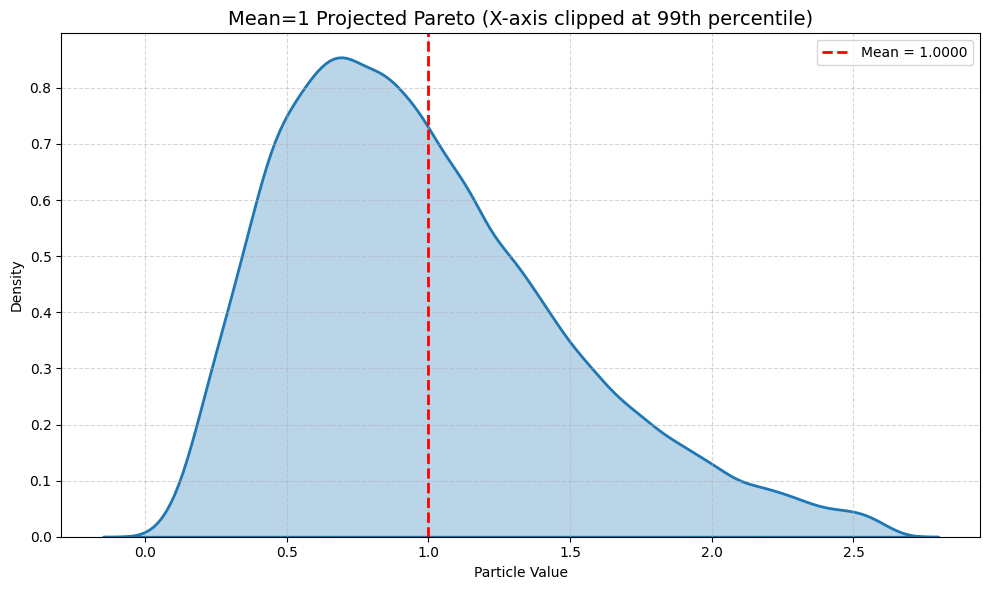

In [8]:
plot_distribution(X, title="Mean=1 Projected Pareto", clip_percentile=99)

#### Check convergence to an $\alpha$ and unique limit distribution



In [8]:
def apply_T(X, u,v, alpha):
    # Sample independent pairs
    X1 = sample_from_empirical(X)
    X2 = sample_from_empirical(X)
    
    # Sample U, I and J
    U = np.random.uniform(0, 1, size=len(X))
    R = np.random.uniform(0, 1, size=len(X))
    
    I = (R < u).astype(np.float64)
    J = ((R >= u) & (R < u + v)).astype(np.float64)
    
    # Apply the operator T_alpha
    term1 = (U**alpha) * X1
    term2 = ((1 - U)**alpha) * X2
    
    T_X = I * (term1 + term2) + J * np.maximum(term1, term2)

    return T_X

def apply_S(X, u, v, alpha):
    Y = apply_T(X, u, v, alpha)
    return Y / np.mean(Y)

In [ ]:
def cummulative_mean(alpha, u, v, X_init, burn_in=15, num_iters=40):
    
    multipliers = []
    
    for i in range(burn_in + num_iters):
        Y = apply_T(X_init, u, v, alpha)
        step_mean = np.mean(Y)

        X = Y / step_mean
                
        # Record the multiplier (ignoring the burn-in period)
        if i >= burn_in:
            multipliers.append(step_mean)
            
    return np.mean(multipliers), X

def find_alpha(u, v, X_init, lower, upper, tolerance=1e-10, max_steps=15):
    """
    Uses bisection search to find the root of cummulative_mean(alpha) = 1.
    """
    print(f"Searching for alpha* for u={u}, v={v}")
    print(f"{'Step':<5} | {'Alpha Estimate':<15} | {'Cumulative Mean':<15}")
    print("-" * 40)
    
    for step in range(max_steps):
        mid_alpha = (lower + upper) / 2.0
        
        # Estimate the growth rate for this alpha
        current_mean, X = cummulative_mean(mid_alpha, u, v, X_init)
        
        print(f"{step+1:<5} | {mid_alpha:<15.5f} | {current_mean:<15.5f}")
        
        # Check for convergence
        if abs(current_mean - 1.0) < tolerance:
            print("-" * 40)
            print(f"Converged! alpha* = {mid_alpha:.5f}")
            return mid_alpha, X
            
        # If current_mean > 1, increase alpha.
        if current_mean > 1.0:
            lower = mid_alpha
        else:
            upper = mid_alpha
            
    print("-" * 40)
    print(f"Reached max steps. Best estimate for alpha* ≈ {mid_alpha:.5f}")
    return mid_alpha, X


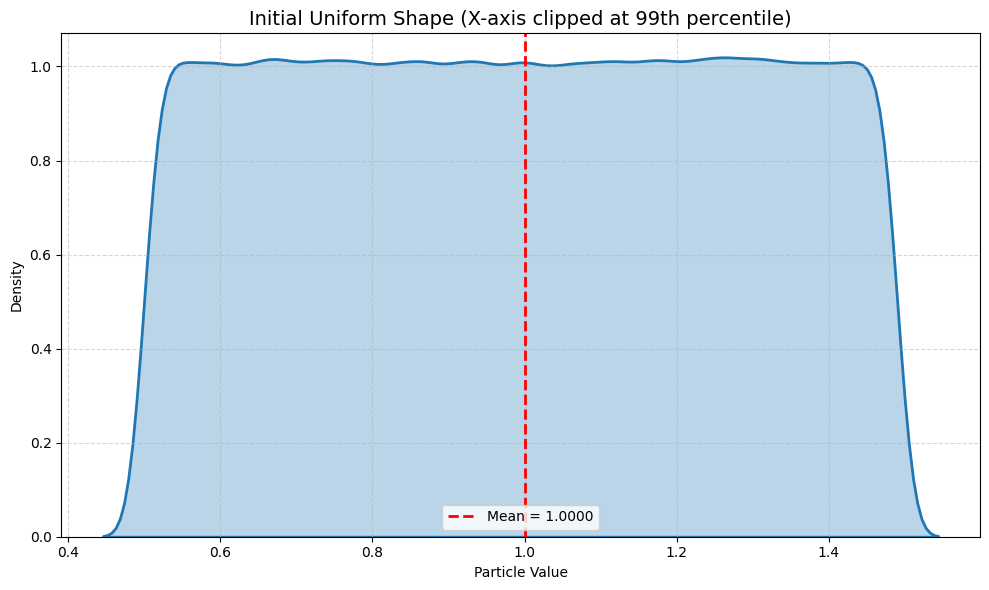

Searching for alpha* for u=0.5, v=0.3
Step  | Alpha Estimate  | Cumulative Mean
----------------------------------------
1     | 0.45000         | 1.01673        
2     | 0.52500         | 0.97165        
3     | 0.48750         | 0.99336        
4     | 0.46875         | 1.00502        
5     | 0.47812         | 0.99923        
6     | 0.47344         | 1.00209        
7     | 0.47578         | 1.00078        
8     | 0.47695         | 1.00019        
9     | 0.47754         | 0.99970        
10    | 0.47725         | 0.99967        
11    | 0.47710         | 0.99986        
12    | 0.47703         | 0.99993        
13    | 0.47699         | 1.00010        
14    | 0.47701         | 0.99974        
15    | 0.47700         | 1.00013        
16    | 0.47700         | 1.00012        
17    | 0.47701         | 1.00003        
18    | 0.47701         | 1.00030        
19    | 0.47701         | 0.99999        
20    | 0.47701         | 1.00012        
---------------------------------------

In [17]:
generator = MeanOneGenerator(size=1000000)
X_init,_,_ = generator.generate_uniform_shape()
plot_distribution(X_init, title="Initial Uniform Shape", clip_percentile=99)
u, v = 0.5, 0.3
alpha_star, X_final = find_alpha(u, v, X_init, lower=0.3, upper=0.6, max_steps=20)

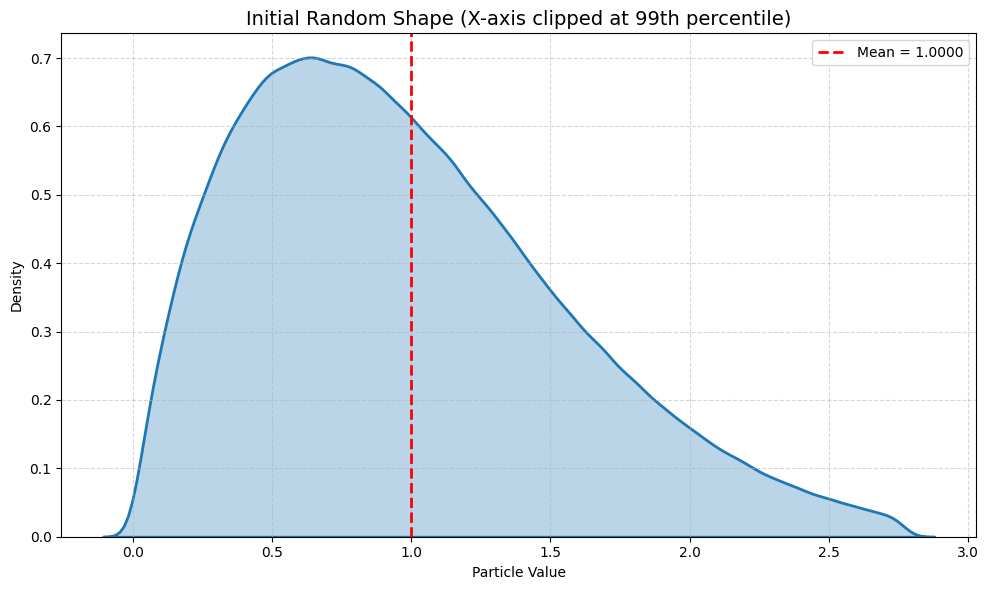

Searching for alpha* for u=0.5, v=0.3
Step  | Alpha Estimate  | Cumulative Mean
----------------------------------------
1     | 0.45000         | 1.01649        
2     | 0.52500         | 0.97153        
3     | 0.48750         | 0.99373        
4     | 0.46875         | 1.00486        
5     | 0.47812         | 0.99945        
6     | 0.47344         | 1.00224        
7     | 0.47578         | 1.00034        
8     | 0.47695         | 0.99999        
9     | 0.47637         | 1.00033        
10    | 0.47666         | 1.00003        
11    | 0.47681         | 0.99997        
12    | 0.47673         | 1.00001        
13    | 0.47677         | 1.00026        
14    | 0.47679         | 1.00010        
15    | 0.47680         | 1.00021        
16    | 0.47680         | 1.00033        
17    | 0.47680         | 1.00021        
18    | 0.47681         | 1.00005        
19    | 0.47681         | 0.99986        
20    | 0.47681         | 0.99997        
---------------------------------------

In [21]:
Y,name,params = generator.generate_random_shape()
print(f"Base Shape: {name} | Parameters: {params}")
plot_distribution(Y, title="Initial Random Shape", clip_percentile=99)
u, v = 0.5, 0.3
alpha_star, Y_final = find_alpha(u, v, Y, lower=0.3, upper=0.6, max_steps=20)

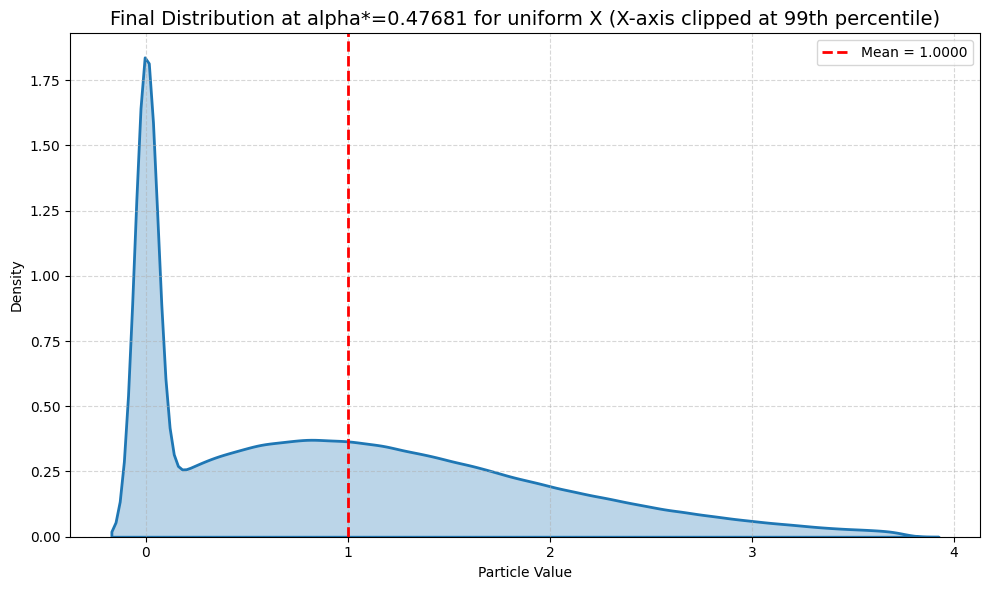

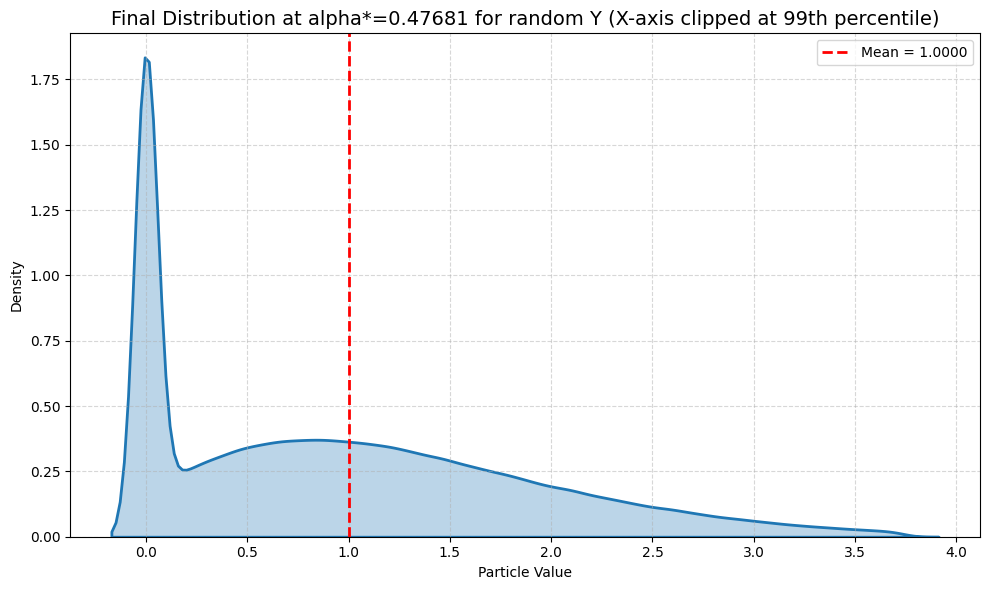

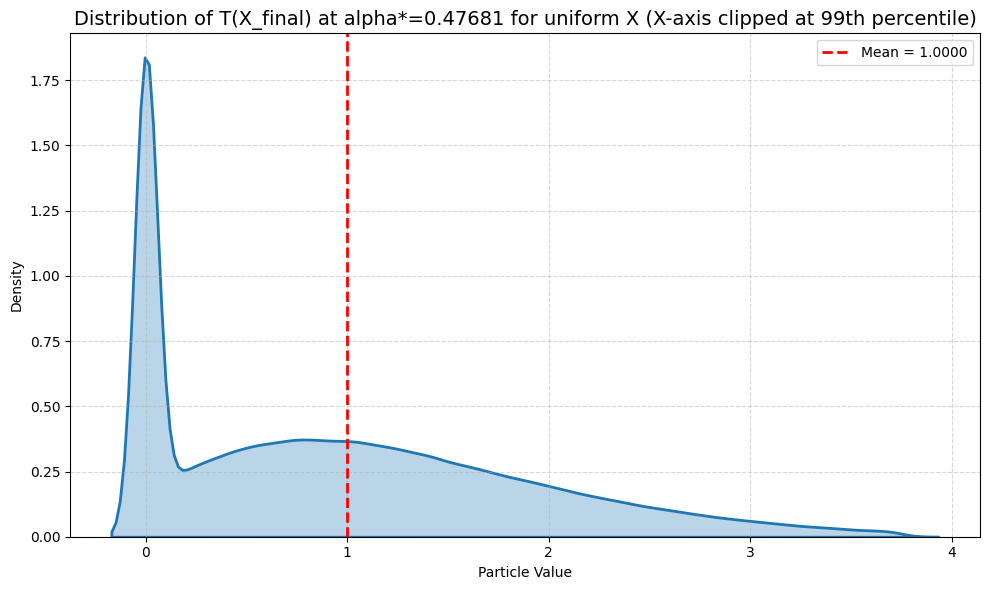

In [22]:
plot_distribution(X_final, title=f"Final Distribution at alpha*={alpha_star:.5f} for uniform X", clip_percentile=99)
plot_distribution(Y_final, title=f"Final Distribution at alpha*={alpha_star:.5f} for random Y", clip_percentile=99)
T_X_final = apply_T(X_final, u, v, alpha_star)
plot_distribution(T_X_final, title=f"Distribution of T(X_final) at alpha*={alpha_star:.5f} for uniform X", clip_percentile=99)

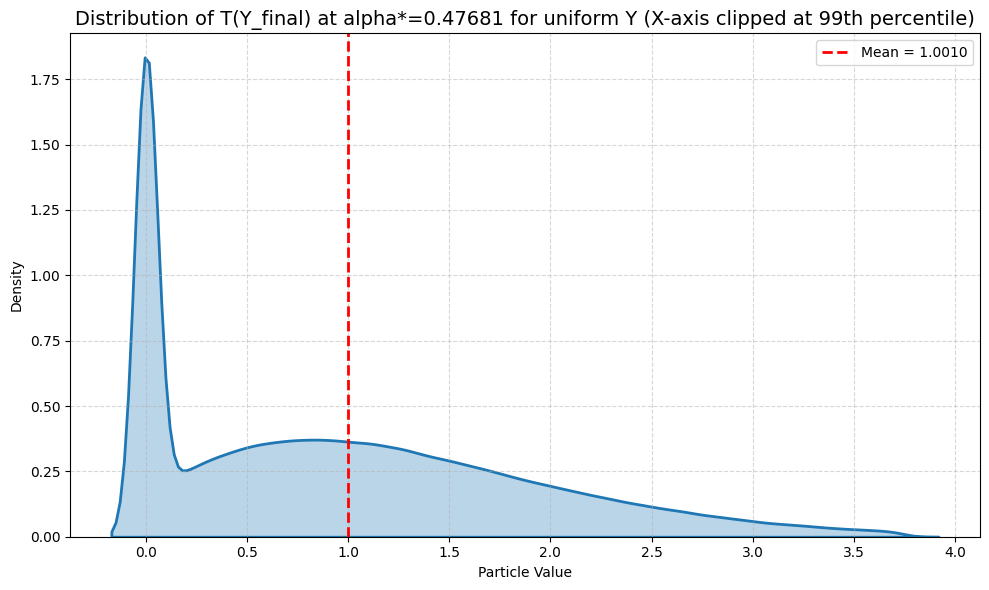

In [23]:
T_Y_final = apply_T(Y_final, u, v, alpha_star)
plot_distribution(T_Y_final, title=f"Distribution of T(Y_final) at alpha*={alpha_star:.5f} for uniform Y", clip_percentile=99)

#### Check if that $\alpha$ is true.

##### Compute distribution of $Y_n$

$$Y_{n} = I\left(Y_{U_n}^{(1)} + Y_{n-1-U_n}^{(2)} + 1\right) + J\max\left(Y_{U_n}^{(1)}, Y_{n-1-U_n}^{(2)}\right), \quad Y_0=Y_2=1.$$

Given that the subscripts are for independent copies. The variables $I$ and $J$ are Bernoulli with expectation $u$ and $v$ respectively such that $I+J\le 1$ and $u+v\le 1$, and they are inpependent of all $Y^{(j)}_i$.

$$\zeta_s()$$

In [30]:
def compute_Yn(max_N, u, v):

    pmfs = [np.array([1.0]), np.array([1.0])]
    cdfs = [np.array([1.0]), np.array([1.0])]
    
    termination_prob = 1.0 - u - v

    for n in range(2, max_N + 1):
        if n % 10 == 0:
            print(f"Computing up to n={n}...")
            
        current_pmf = np.zeros(n)
        
        # U_n is uniform over {0, ..., n-1}
        # Evaluate up to floor(n/2) and double the weights for symmetry
        for k in range((n + 1) // 2):
            j = n - 1 - k
            weight = 2.0 if k != j else 1.0
            
            # Concatenation: convolution
            conv_pmf = np.convolve(pmfs[k], pmfs[j])
            concat_pmf = np.zeros(len(conv_pmf) + 1)

            # Shift by 1 for the "+ 1"
            concat_pmf[1:] = conv_pmf  
            
            length_c = min(len(concat_pmf), n)
            current_pmf[:length_c] += weight * u * concat_pmf[:length_c]
            
            # Alternation
            len_k = len(cdfs[k])
            len_j = len(cdfs[j])
            max_len = max(len_k, len_j)
            
            cdf_k_ext = np.ones(max_len)
            cdf_k_ext[:len_k] = cdfs[k]
            
            cdf_j_ext = np.ones(max_len)
            cdf_j_ext[:len_j] = cdfs[j]
            
            cdf_max = cdf_k_ext * cdf_j_ext
            
            pmf_max = np.zeros(max_len)
            pmf_max[0] = cdf_max[0]
            pmf_max[1:] = cdf_max[1:] - cdf_max[:-1]
            
            length_m = min(len(pmf_max), n)
            current_pmf[:length_m] += weight * v * pmf_max[:length_m]

        # Average over the uniform choice of U_n
        current_pmf /= n
        
        # Termination
        current_pmf[0] += termination_prob
        
        # Correct floating-point inaccuracies
        current_pmf = np.maximum(current_pmf, 0)
        current_pmf /= np.sum(current_pmf)
        
        pmfs.append(current_pmf)
        cdfs.append(np.cumsum(current_pmf))
    
    expectations = [np.sum(pmf * np.arange(len(pmf))) for pmf in pmfs]
        
    return pmfs, cdfs, expectations

Computing up to n=10...
Computing up to n=20...
Computing up to n=30...
Computing up to n=40...
Computing up to n=50...
Computing up to n=60...
Computing up to n=70...
Computing up to n=80...
Computing up to n=90...
Computing up to n=100...
Computing up to n=110...
Computing up to n=120...
Computing up to n=130...
Computing up to n=140...
Computing up to n=150...
Computing up to n=160...
Computing up to n=170...
Computing up to n=180...
Computing up to n=190...
Computing up to n=200...
Computing up to n=210...
Computing up to n=220...
Computing up to n=230...
Computing up to n=240...
Computing up to n=250...
Computing up to n=260...
Computing up to n=270...
Computing up to n=280...
Computing up to n=290...
Computing up to n=300...
Computing up to n=310...
Computing up to n=320...
Computing up to n=330...
Computing up to n=340...
Computing up to n=350...
Computing up to n=360...
Computing up to n=370...
Computing up to n=380...
Computing up to n=390...
Computing up to n=400...
Computing

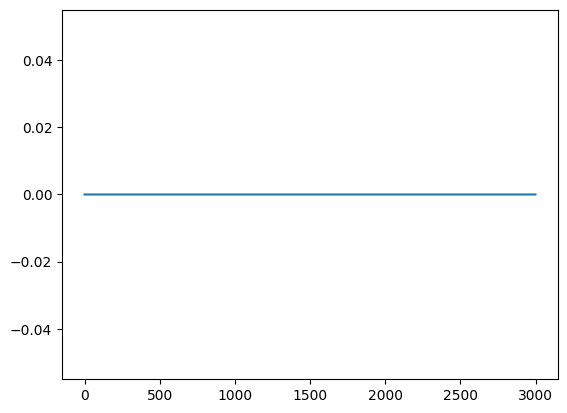

In [31]:
pmfs, cdfs, expectations = compute_Yn(max_N=3000, u=0.5, v=0.3)
plt.plot(expectations[:1]/np.arange(1, len(expectations))**alpha_star)

In [64]:
# Save computations
from pathlib import Path
import numpy as np

# Determine an output directory called 'distributions'.
# Try several likely locations relative to the current working directory.
cwd = Path.cwd()
candidates = [
    cwd / 'distributions',
    cwd.parent / 'distributions',
    cwd.parent.parent / 'distributions',
]
out_dir = next((p for p in candidates if p.exists()), candidates[1])
out_dir.mkdir(parents=True, exist_ok=True)

# Save pmfs (one file per n)
for n, pmf in enumerate(pmfs):
    fname = out_dir / f'pmf_{n}.txt'
    np.savetxt(fname, pmf, fmt='%.18e')

# Save cdfs (one file per n)
for n, cdf in enumerate(cdfs):
    fname = out_dir / f'cdf_{n}.txt'
    np.savetxt(fname, cdf, fmt='%.18e')

# Save expectations to a single text file
exp_file = out_dir / 'expectations.txt'
with exp_file.open('w') as fh:
    for n, e in enumerate(expectations):
        fh.write(f"{n}	{e:.18e}\n")

print(f'Wrote {len(pmfs)} pmf files, {len(cdfs)} cdf files, and {len(expectations)} expectations to {out_dir}')

Wrote 3001 pmf files, 3001 cdf files, and 3001 expectations to d:\Projects\m2-bezout\internship\src\notebooks\distributions


In [61]:
alpha_star

0.47710103988647456

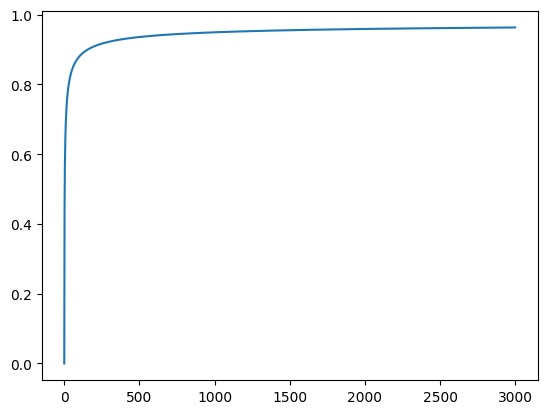

In [63]:
plt.plot(expectations[1:]/np.arange(1, len(expectations))**alpha_star)

#### Check if $S_\alpha = \dfrac{T_\alpha}{\mathbb{E}[T_\alpha]}$ has a fixed point

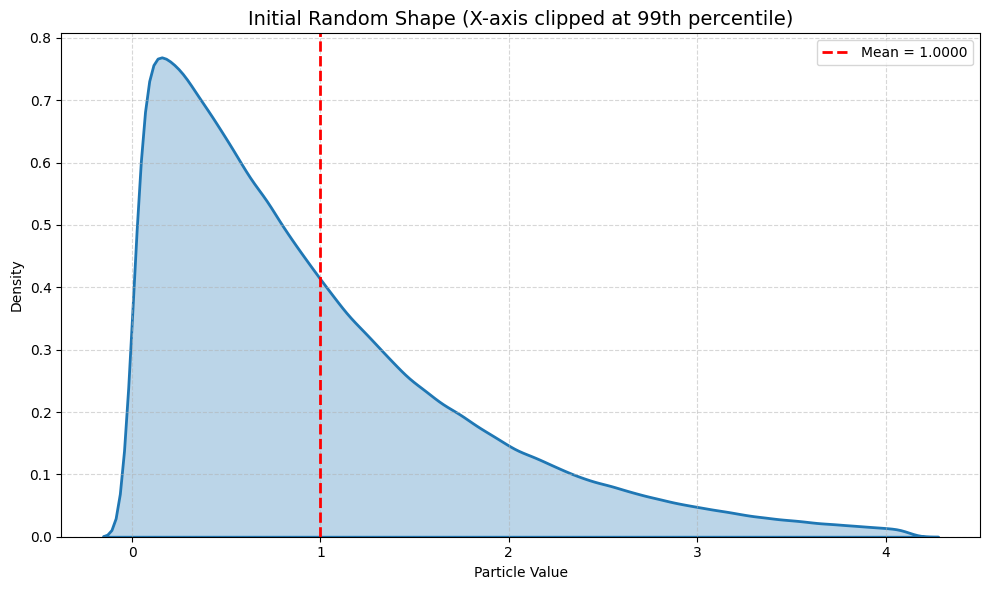

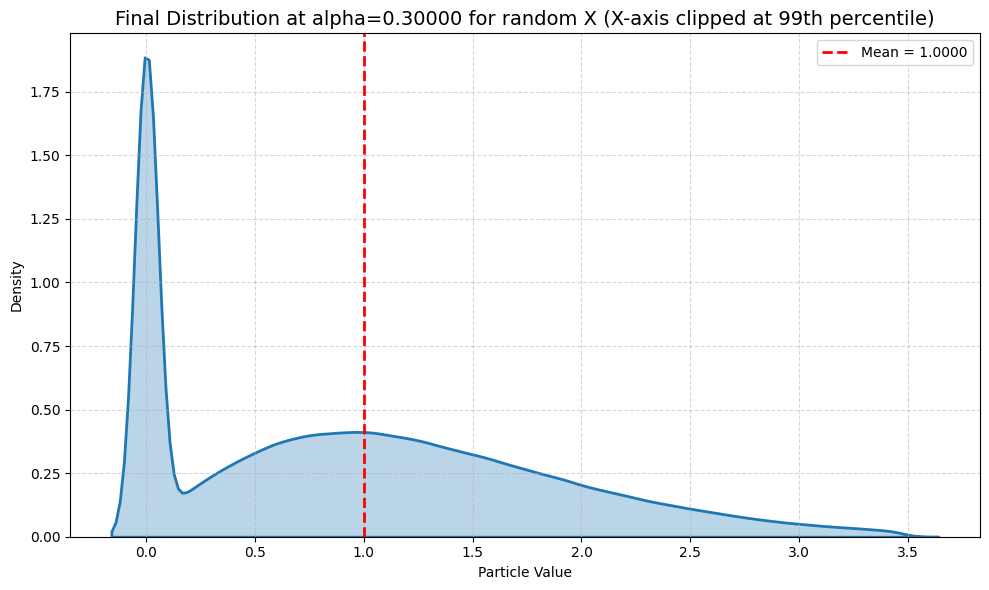

In [12]:
generator = MeanOneGenerator(size=1000000)

X_init,_,_ = generator.generate_random_shape()
plot_distribution(X_init, title="Initial Random Shape", clip_percentile=99)

alpha = 0.3
u, v = 0.5, 0.3

X = X_init

for _ in range(20):
    X = apply_S(X, u, v, alpha)

plot_distribution(X, title=f"Final Distribution at alpha={alpha:.5f} for random X", clip_percentile=99)

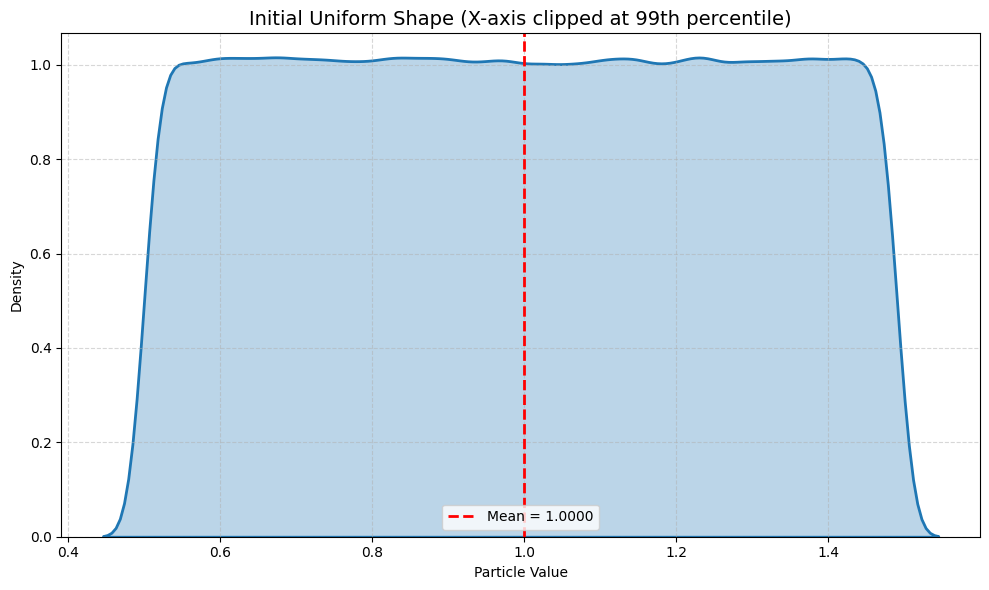

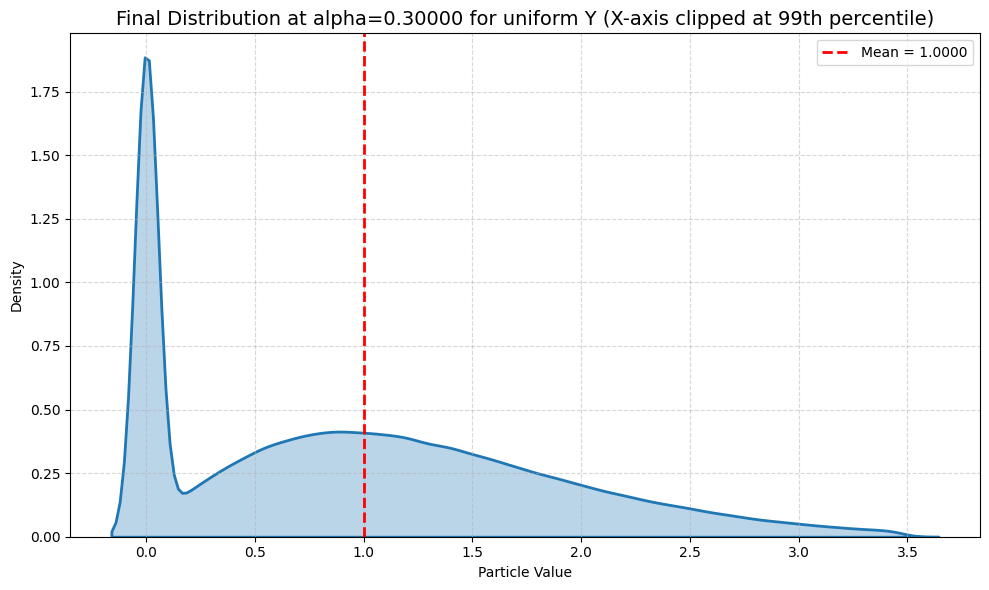

In [13]:
Y_init,_,_ = generator.generate_uniform_shape()
plot_distribution(Y_init, title="Initial Uniform Shape", clip_percentile=99)

Y = Y_init

for _ in range(20):
    Y = apply_S(Y, u, v, alpha)

plot_distribution(Y, title=f"Final Distribution at alpha={alpha:.5f} for uniform Y", clip_percentile=99)